# Cardiovascular Disease Prediction

This notebook analyzes the Cardiovascular Study Dataset to predict the 10-year risk of coronary heart disease (CHD) using a logistic regression model. The goal is to understand the strongest risk factors and to build a model that can support clinical decision-making.

## Project Goal
We want to answer the question: Which patient characteristics are the strongest predictors of CHD, and how accurately can we classify a patient as high-risk?

## Main Problem Question
If a patient has certain health and lifestyle characteristics, what is the probability that they will develop CHD within the next 10 years?

## Why This Matters
Early identification of high-risk patients can help doctors intervene sooner and reduce the chance of serious outcomes.

# **Cardiovascular Disease Prediction**

The purpose of this notebook is to analyse the Cardiovascular Study Dataset and perform an analysis and fit a logistic regression model for predicting the 10-year risk of coronary heart disease (CHD).

## Introduction  
Given a patient health and lifestyle information- can we predict whether they will develop coronary heart disease in the next 10 years? 
Getting it right, the doctor can intervene and the patient survives otherwise the patient may die due to no intervention.

The structure roughly follows:
- Data Loading and Cleaning
- EDA
- Modelling
- Interpretation and Conclusion

## Main Problem Question
Which patient characteristics are the strongest predictors of 10 years coronary heart disease risk and at what probability threshold should we classify a patient as high risk to maximise the clinical value of this model?

### Analysis Questions
1. Why logistic regression and not linear regression?
2. Why did you choose those specific variables?
3. Why did you drop or keep certain variables with missing data?
4. Why did you choose that specific threshold?
5. What does each coefficient actually mean medically?
6. Which metric matters most and why?
7. What are the limitations of your model?

## **Data Loading and Cleaning**

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [49]:
import os
from pathlib import Path

# Try the local project folder first, then the workspace, then Downloads.
possible_paths = [
    Path("C:/Users/ezion/OneDrive/TURING COLLEGE/Module 4- PYTHON/M4S4 Project/train.csv"),
    Path.cwd() / "train.csv",
    Path.home() / "Downloads" / "train.csv",
]

for path in possible_paths:
    if path.exists():
        file_path = str(path)
        break
else:
    try:
        import kagglehub
        download_dir = kagglehub.dataset_download("christofel04/cardiovascular-study-dataset-predict-heart-disea")
        file_path = str(Path(download_dir) / "train.csv")
    except Exception as exc:
        raise FileNotFoundError(
            "The dataset could not be found automatically. Please place train.csv in the notebook folder or update the file_path cell."
        ) from exc

print("Using file:", file_path)


Using file: C:\Users\ezion\OneDrive\TURING COLLEGE\Module 4- PYTHON\M4S4 Project\train.csv


In [50]:
df = pd.read_csv(file_path)

In [9]:
print("Shape:", df.shape)

Shape: (3390, 17)


In [14]:
print("\nColumn names:") 
print (df.columns.tolist())


Column names:
['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [13]:
print("\nData types:")
print(df.dtypes)


Data types:
id                   int64
age                  int64
education          float64
sex                    str
is_smoking             str
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


In [15]:
print("\nTarget variable distribution:")
print(df['TenYearCHD'].value_counts())
print(df['TenYearCHD'].value_counts(normalize=True))


Target variable distribution:
TenYearCHD
0    2879
1     511
Name: count, dtype: int64
TenYearCHD
0    0.849263
1    0.150737
Name: proportion, dtype: float64


Having checked the variables in the dataset, the 'id' column will not be used becuase it is just a patient identifier and has no predictive value.

In [16]:
df = df.drop(columns=['id'])
print(df.shape)

(3390, 16)


Checking for Missing Values

In [17]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64


In [18]:
print("\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing percentage:
age                0.00
education          2.57
sex                0.00
is_smoking         0.00
cigsPerDay         0.65
BPMeds             1.30
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.12
sysBP              0.00
diaBP              0.00
BMI                0.41
heartRate          0.03
glucose            8.97
TenYearCHD         0.00
dtype: float64


**glucose** is missing 9% of values. In dropping the column we may lose important medical predictor because glucose is strongly linked to diabetes and CHD risk.
**glucose** is too medically important to be discarded. The column will be kept and the missing values will be replaced with the median.

In [19]:
print("CATEGORICAL variables (binary 0\1)")
binary_cols = ['sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
for col in binary_cols:
    print(f"{col}: {df[col].value_counts().to_dict()}")


CATEGORICAL variables (binary 0)
sex: {'F': 1923, 'M': 1467}
is_smoking: {'NO': 1703, 'YES': 1687}
BPMeds: {0.0: 3246, 1.0: 100}
prevalentStroke: {0: 3368, 1: 22}
prevalentHyp: {0: 2321, 1: 1069}
diabetes: {0: 3303, 1: 87}


In [27]:
print("\nNUMERICAL variables:")
numerical_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
print(df[numerical_cols].describe().round(2))
# Shows ALL columns including categorical!


NUMERICAL variables:
           age  cigsPerDay  totChol    sysBP    diaBP      BMI  heartRate  \
count  3390.00     3368.00  3352.00  3390.00  3390.00  3376.00    3389.00   
mean     49.54        9.07   237.07   132.60    82.88    25.79      75.98   
std       8.59       11.88    45.25    22.29    12.02     4.12      11.97   
min      32.00        0.00   107.00    83.50    48.00    15.96      45.00   
25%      42.00        0.00   206.00   117.00    74.50    23.02      68.00   
50%      49.00        0.00   234.00   128.50    82.00    25.38      75.00   
75%      56.00       20.00   264.00   144.00    90.00    28.04      83.00   
max      70.00       70.00   696.00   295.00   142.50    56.80     143.00   

       glucose  
count  3086.00  
mean     82.09  
std      24.24  
min      40.00  
25%      71.00  
50%      78.00  
75%      87.00  
max     394.00  


age        → 32 to 70 years, mean 49.5 → reasonable range

cigsPerDay → mean 9, max 70!
             25% and 50% are ZERO → most people don't smoke
             but some smoke heavily → right skewed!

totChol    → mean 237, max 696!!
             normal range is below 200
             max of 696 is extremely high → likely outlier!

sysBP      → mean 132, max 295!!
             normal systolic BP is below 120
             295 is dangerously high → likely outlier!

diaBP      → max 142.5
             normal diastolic is below 80
             142.5 is very high → potential outlier!

BMI        → mean 25.8, max 56.8
             healthy BMI is 18.5-24.9
             56.8 is severely obese → potential outlier!

heartRate  → max 143
             possible but worth checking!

glucose    → mean 82, max 394!!
             normal fasting glucose is 70-100
             394 is extremely high → diabetic crisis level!
             → definite outlier!

Checking Target Distribution

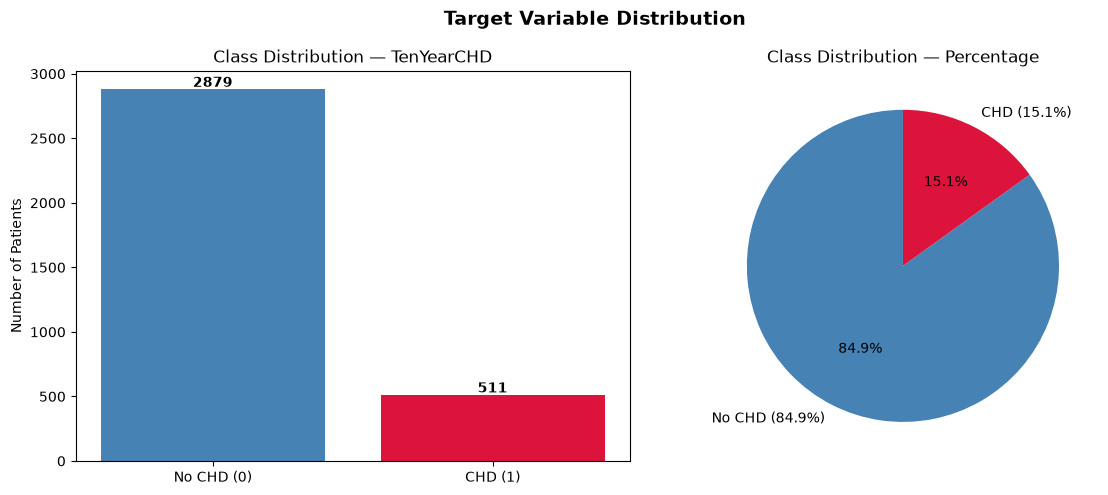

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['No CHD (0)', 'CHD (1)'], 
            df['TenYearCHD'].value_counts(),
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution — TenYearCHD')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(df['TenYearCHD'].value_counts()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')


    # Percentage plot
axes[1].pie(df['TenYearCHD'].value_counts(),
            labels=['No CHD (84.9%)', 'CHD (15.1%)'],
            colors=['steelblue', 'crimson'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Distribution — Percentage')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

# Split BEFORE any cleaning or processing!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # ensures both splits have same class ratio!
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set:  {X_test.shape[0]} patients")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 2712 patients
Testing set:  678 patients

Training target distribution:
TenYearCHD
0    0.849
1    0.151
Name: proportion, dtype: float64

Testing target distribution:
TenYearCHD
0    0.85
1    0.15
Name: proportion, dtype: float64


Stratifying the data ensures that there is a fair distribution. Both training and testing data have the same distribution of health and sick at 84.9% and 15.1% respectively.

**Handling Class Imbalance**

In [29]:
# Separate majority and minority classes
X_train_majority = X_train[y_train == 0]
X_train_minority = X_train[y_train == 1]

y_train_majority = y_train[y_train == 0]
y_train_minority = y_train[y_train == 1]

print(f"Majority class (no CHD): {len(X_train_majority)}")
print(f"Minority class (CHD):    {len(X_train_minority)}")

Majority class (no CHD): 2303
Minority class (CHD):    409


**Downsampling the Majority Class**

In [30]:
from sklearn.utils import resample

# Downsample majority class to match minority
X_train_majority_downsampled = resample(
    X_train_majority,
    replace=False,        # sample WITHOUT replacement
    n_samples=len(X_train_minority),  # match minority count
    random_state=42
)

y_train_majority_downsampled = resample(
    y_train_majority,
    replace=False,
    n_samples=len(X_train_minority),
    random_state=42
)

# Combine minority and downsampled majority
import pandas as pd

X_train_balanced = pd.concat([
    X_train_majority_downsampled,
    X_train_minority
])

y_train_balanced = pd.concat([
    y_train_majority_downsampled,
    y_train_minority
])

print(f"\nBalanced training set:")
print(f"Total patients: {len(X_train_balanced)}")
print(f"Class distribution:")
print(y_train_balanced.value_counts())
print(y_train_balanced.value_counts(normalize=True).round(3))


Balanced training set:
Total patients: 818
Class distribution:
TenYearCHD
0    409
1    409
Name: count, dtype: int64
TenYearCHD
0    0.5
1    0.5
Name: proportion, dtype: float64


This tool is being built to identify people at risk of heart disease. Downsampling ensures the model learns that both outcomes, sick or healthy, are equally possible. The model is now able to find real patterns that distinguish sick from healthy.


In [35]:
print(X_train_balanced.dtypes)
print("\nUnique values in sex column:")
print(X_train_balanced['sex'].unique())
print("\nUnique values in is_smoking column:")
print(X_train_balanced['is_smoking'].unique())

age                  int64
education          float64
sex                    str
is_smoking             str
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
dtype: object

Unique values in sex column:
<StringArray>
['M', 'F']
Length: 2, dtype: str

Unique values in is_smoking column:
<StringArray>
['YES', 'NO']
Length: 2, dtype: str


In [ ]:
# Convert the binary categorical variables to numeric codes.
# This is necessary so the logistic regression model can use them.
X_train_balanced['sex'] = X_train_balanced['sex'].map({'M': 1, 'F': 0})
X_test['sex'] = X_test['sex'].map({'M': 1, 'F': 0})

X_train_balanced['is_smoking'] = X_train_balanced['is_smoking'].map({'YES': 1, 'NO': 0})
X_test['is_smoking'] = X_test['is_smoking'].map({'YES': 1, 'NO': 0})

# Make sure the categorical columns are now numeric.
print("Sex unique values:", X_train_balanced['sex'].unique())
print("is_smoking unique values:", X_train_balanced['is_smoking'].unique())
print("\nUpdated data types:")
print(X_train_balanced.dtypes)

Sex unique values: [1 0]
is_smoking unique values: [1 0]

Data types:
age                  int64
education          float64
sex                  int64
is_smoking           int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
dtype: object


**Missing Values on Training Data**

 totChol mean = 237 but max = 696 (extreme outlier!)
→ Mean is PULLED UP by that extreme value!
→ Median = 234 → true middle value → better fill!

glucose mean = 82 but max = 394!
→ Same problem → median is safer!

Medical data almost always has extreme outliers
→ ALWAYS use median for medical imputation!

In [51]:
from sklearn.impute import SimpleImputer

# Reset indices so the features and target stay aligned.
X_train_balanced = X_train_balanced.reset_index(drop=True)
y_train_balanced = y_train_balanced.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# Use median imputation for the training data only.
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_balanced)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train_balanced.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

print("Missing values in training after imputation:", X_train_imputed.isnull().sum().sum())
print("Missing values in testing after imputation:", X_test_imputed.isnull().sum().sum())
print(f"Training shape: {X_train_imputed.shape}")
print(f"Testing shape:  {X_test_imputed.shape}")

Missing values in training after imputation: 0
Missing values in testing after imputation: 0
Training shape: (818, 15)
Testing shape:  (678, 15)


## EDA

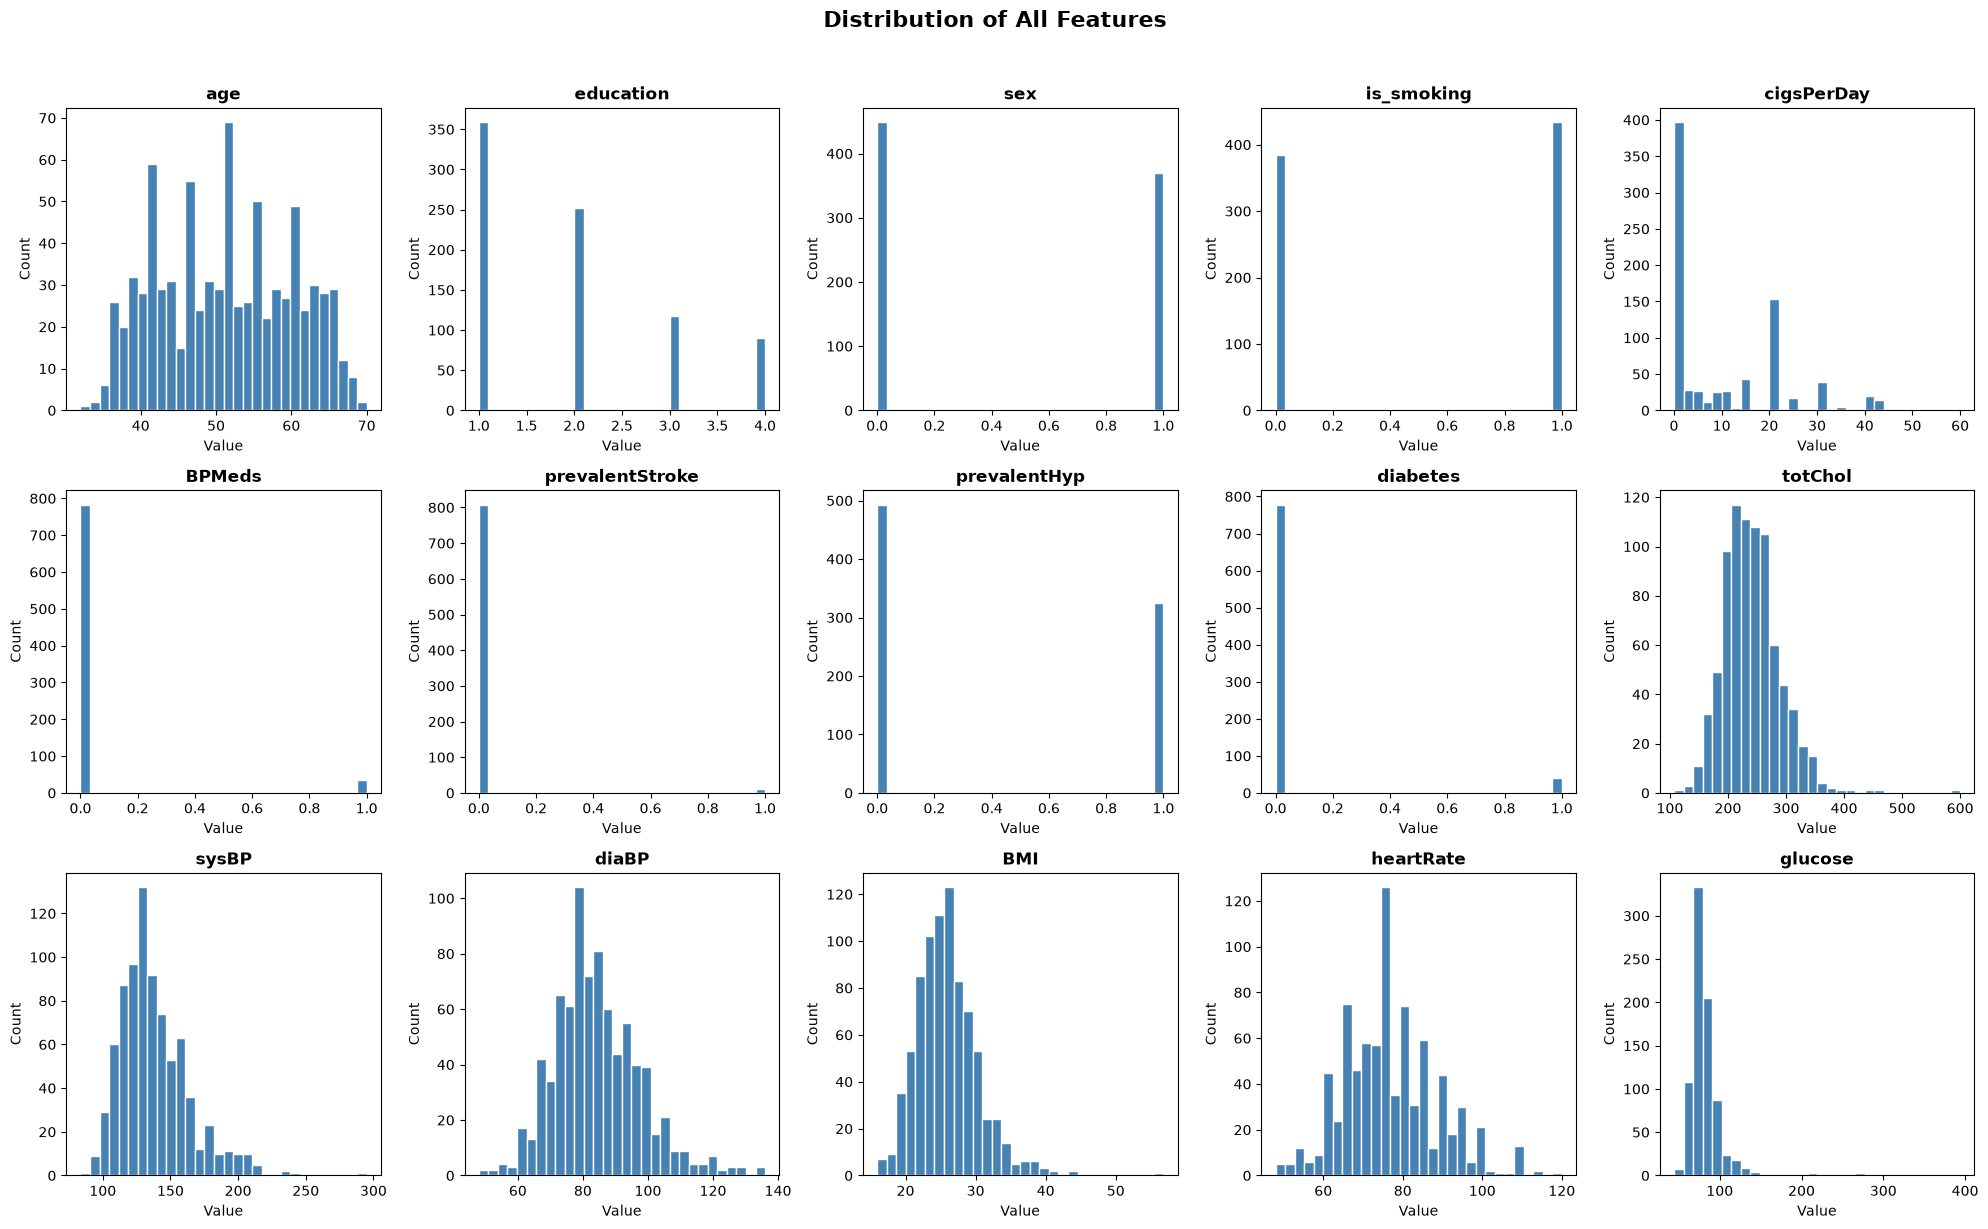

In [38]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(X_train_imputed.columns):
    axes[i].hist(X_train_imputed[col], bins=30, 
                 color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Features', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

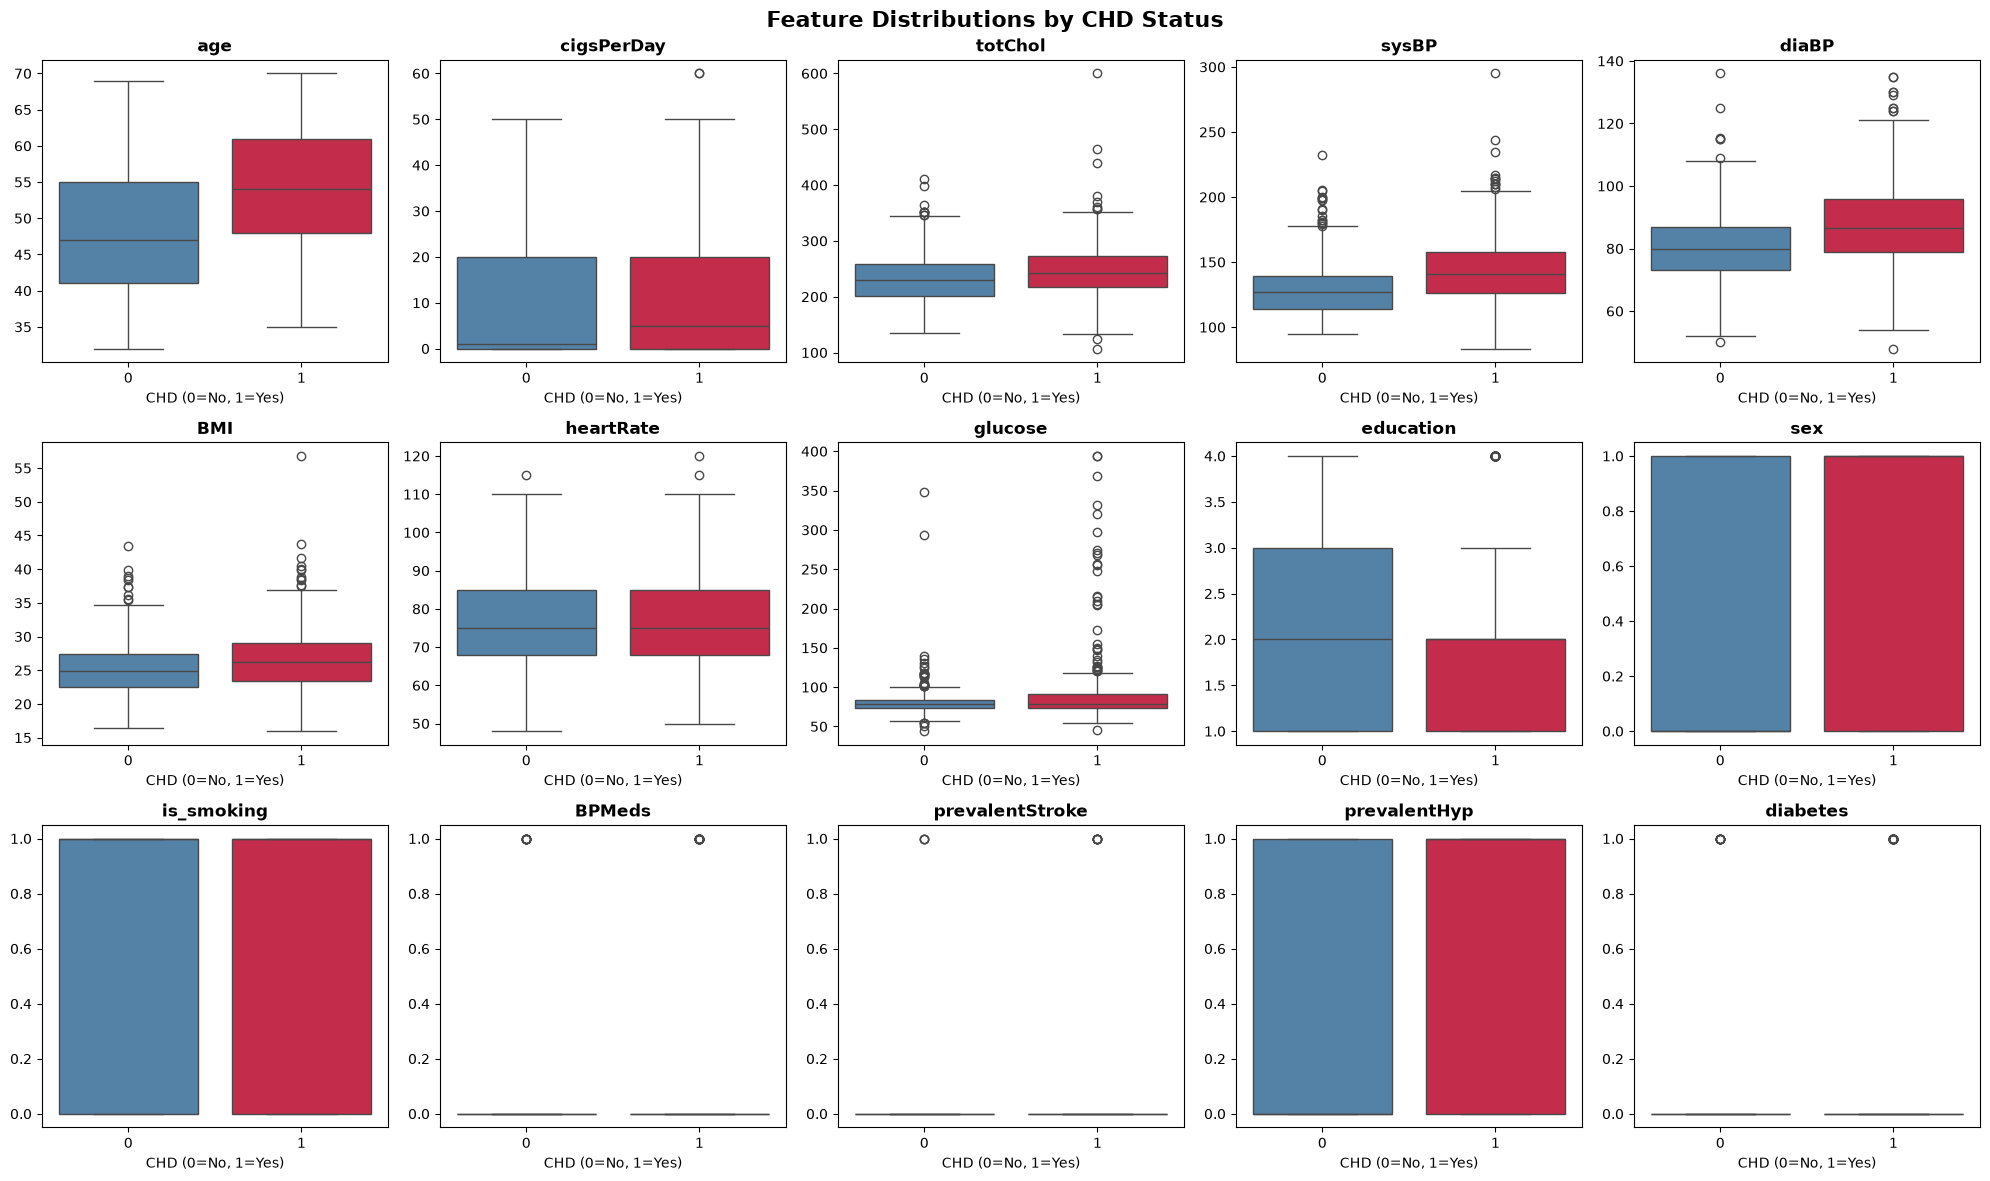

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

train_plot = X_train_imputed.copy()
train_plot['TenYearCHD'] = y_train_balanced.values

all_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
            'education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

for ax, col in zip(axes, all_cols):
    sns.boxplot(
        data=train_plot,
        x='TenYearCHD',
        y=col,
        hue='TenYearCHD',
        palette={0: 'steelblue', 1: 'crimson'},
        legend=False,
        ax=ax
    )
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('CHD (0=No, 1=Yes)')
    ax.set_ylabel('')

plt.suptitle('Feature Distributions by CHD Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Age:
Patients with no CHD have a median age of ~47 years while patients with CHD have a median age of 54 years.
This strongly shows that CHD patients are significantly OLDER. Age is important.

SysBP:
No CHD median  → ~125
CHD median     → ~145
→ CHD patients have significantly HIGHER blood pressure!
→ Include this!

diaBP:
No CHD median diaBP → ~80
CHD median     → ~88
→ Some difference → worth including!


glucose:
No CHD median  → ~75
CHD median     → ~85
→ CHD patients have higher glucose
→ Many outliers visible!

cigsPerDay:
Both groups look very similar
Lots of overlap
Median similar for both groups

totChol:
Very similar distributions
Extreme outliers in both groups
Little separation between groups

heartRate:
Almost identical distributions!
Median barely differs
→ Probably not useful!

BMI:
Very similar distributions
Little visual separation

**Correlation**

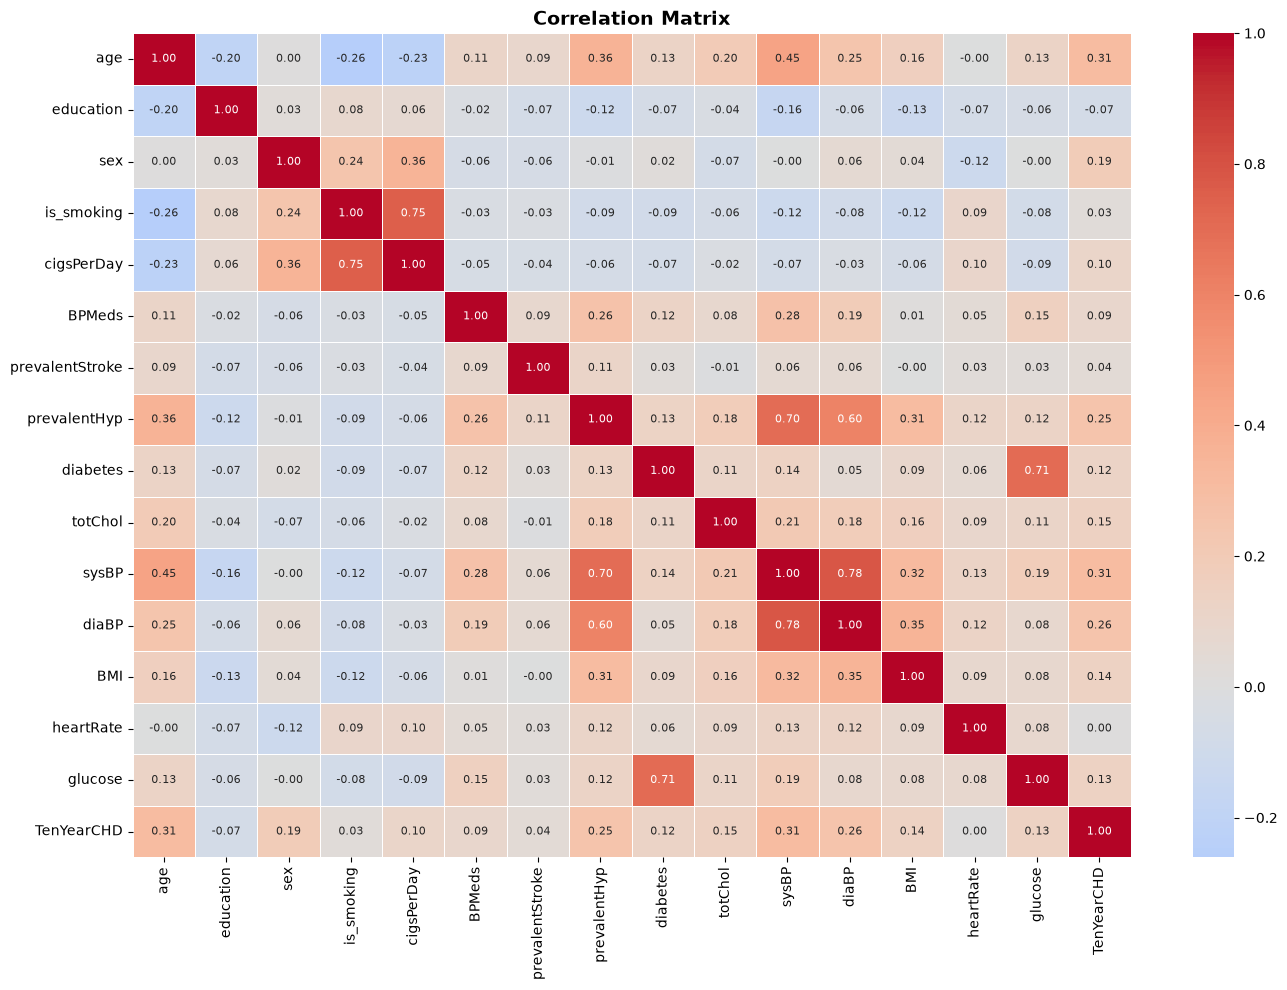


Correlations with TenYearCHD (sorted by strength):
age                0.310
sysBP              0.306
diaBP              0.256
prevalentHyp       0.252
sex                0.189
totChol            0.146
BMI                0.138
glucose            0.134
diabetes           0.125
cigsPerDay         0.104
BPMeds             0.091
education          0.070
prevalentStroke    0.044
is_smoking         0.034
heartRate          0.004
Name: TenYearCHD, dtype: float64


In [44]:
# Add target back temporarily for correlation
train_with_target = X_train_imputed.copy()
train_with_target['TenYearCHD'] = y_train_balanced.values

plt.figure(figsize=(14, 10))
correlation_matrix = train_with_target.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target specifically
print("\nCorrelations with TenYearCHD (sorted by strength):")
target_corr = correlation_matrix['TenYearCHD']\
    .drop('TenYearCHD')\
    .abs()\
    .sort_values(ascending=False)
print(target_corr.round(3))

Looking at correlations with TenYearCHD,
age             → 0.31  
sysBP           → 0.31  
diaBP           → 0.26 
prevalentHyp    → 0.25  
totChol         → 0.15  
sex             → 0.19  
BMI             → 0.14  
glucose         → 0.13  
BPMeds          → 0.09  
cigsPerDay      → 0.10  
diabetes        → 0.12  
is_smoking      → 0.03  
education       → -0.07
prevalentStroke → 0.04 
heartRate - 0.00

There are high correlations between features:
sysBP & diaBP        → 0.78 
sysBP & prevalentHyp → 0.70 
diaBP & prevalentHyp → 0.60 
is_smoking & cigsPerDay → 0.75 
diabetes & glucose   → 0.71 

This raises the problem of Multicollinearity; a case where two variables are giving the same information. Coefficients can become unreliable due to this problem, therefore, some features will be dropped.

KEEP → age          (0.31 correlation, medically crucial)
KEEP → sysBP        (0.31 correlation, strong predictor)
DROP → diaBP        (0.78 correlation WITH sysBP → redundant!)
DROP → prevalentHyp (0.70 correlation WITH sysBP → redundant!)
KEEP → totChol      (0.15 correlation, medically important)
KEEP → sex          (0.19 correlation, known CHD risk factor)
KEEP → BMI          (0.14 correlation, obesity is a risk factor)
KEEP → glucose      (0.13 correlation, diabetes indicator)
KEEP → diabetes     (medically important despite weak correlation)
DROP → is_smoking   (0.75 correlation WITH cigsPerDay → redundant!)
KEEP → cigsPerDay   (slightly stronger predictor than is_smoking)
DROP → heartRate    (0.00 correlation → useless!)
DROP → education    (-0.07 → very weak)
DROP → prevalentStroke (0.04 → very weak)
KEEP → BPMeds       (medically relevant — on medication = existing risk)

## Feature Selection

Variables DROPPED and why:

diaBP → correlation of 0.78 with sysBP
        highly redundant — sysBP retained as stronger predictor

prevalentHyp → correlation of 0.70 with sysBP  
               hypertension is already captured by sysBP values

is_smoking → correlation of 0.75 with cigsPerDay
             cigsPerDay provides more granular smoking information

heartRate → correlation of 0.00 with TenYearCHD
            no predictive value whatsoever

education → correlation of -0.07 with TenYearCHD
            negligible predictive value

prevalentStroke → correlation of 0.04 with TenYearCHD
                  very rare condition, minimal predictive power

Variables KEPT and why:
age, sysBP → strongest correlations (0.31 each)
sex        → known medical risk factor for CHD
cigsPerDay → smoking intensity directly linked to CHD risk
BPMeds     → indicates existing cardiovascular treatment
diabetes   → metabolic condition strongly linked to CHD
totChol    → elevated cholesterol is a primary CHD risk factor
BMI        → obesity increases cardiovascular risk
glucose    → blood sugar levels linked to metabolic syndrome

In [45]:
selected_features = [
    'age',          # strongest predictor
    'sex',          # known CHD risk factor
    'cigsPerDay',   # smoking intensity
    'BPMeds',       # existing blood pressure treatment
    'diabetes',     # metabolic risk factor
    'totChol',      # cholesterol level
    'sysBP',        # blood pressure (kept over diaBP)
    'BMI',          # obesity indicator
    'glucose'       # blood sugar level
]

# Apply feature selection
X_train_selected = X_train_imputed[selected_features]
X_test_selected  = X_test_imputed[selected_features]

print("Selected features:", selected_features)
print(f"Training shape: {X_train_selected.shape}")
print(f"Testing shape:  {X_test_selected.shape}")

Selected features: ['age', 'sex', 'cigsPerDay', 'BPMeds', 'diabetes', 'totChol', 'sysBP', 'BMI', 'glucose']
Training shape: (818, 9)
Testing shape:  (678, 9)


Handling Outliers

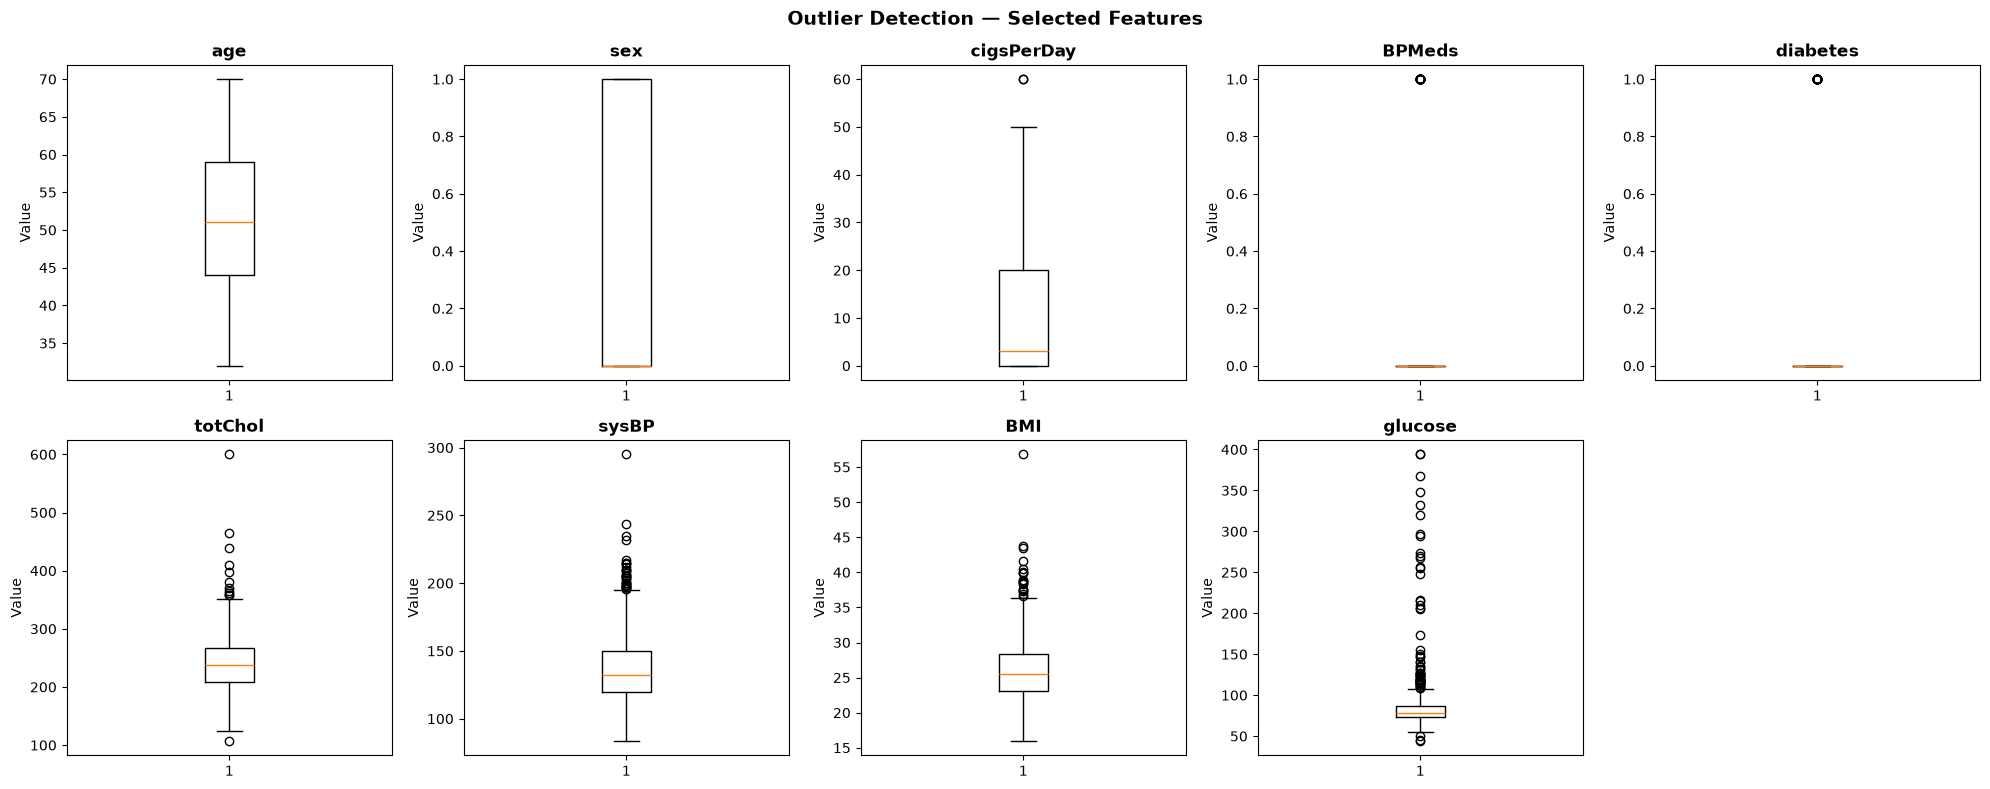

Outlier counts per feature:
----------------------------------------
age          →   0 outliers (0.0%)
sex          →   0 outliers (0.0%)
cigsPerDay   →   2 outliers (0.2%)
BPMeds       →  35 outliers (4.3%)
diabetes     →  40 outliers (4.9%)
totChol      →  12 outliers (1.5%)
sysBP        →  31 outliers (3.8%)
BMI          →  20 outliers (2.4%)
glucose      →  62 outliers (7.6%)


In [46]:
# First visualise outliers in selected features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    axes[i].boxplot(X_train_selected[col].dropna())
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

# Hide the last empty subplot
axes[9].set_visible(False)

plt.suptitle('Outlier Detection — Selected Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print outlier counts using IQR method
print("Outlier counts per feature:")
print("-" * 40)
for col in selected_features:
    Q1 = X_train_selected[col].quantile(0.25)
    Q3 = X_train_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    outliers = X_train_selected[
        (X_train_selected[col] < lower) | 
        (X_train_selected[col] > upper)
    ]
    pct = len(outliers) / len(X_train_selected) * 100
    print(f"{col:12} → {len(outliers):3d} outliers ({pct:.1f}%)")

age        → 0 outliers → nothing to do ✅

sex        → 0 outliers → nothing to do ✅

cigsPerDay → 2 outliers at 60 cigarettes/day
             → 3 packs a day is extreme but possible!
             → Keep but cap at 60 (already the max)
             → Only 2 patients → negligible impact!

BPMeds     → outlier is 1.0 → BINARY variable!
             → DO NOT REMOVE → genuine medical data! ✅

diabetes   → outlier is 1.0 → BINARY variable!
             → DO NOT REMOVE → genuine medical data! ✅

totChol    → outlier at 600
             → Normal range is below 200
             → 600 is extremely high but clinically possible
               (familial hypercholesterolemia)
             → Cap using IQR upper fence

sysBP      → outlier at 300
             → Normal systolic is below 120
             → 295 is a hypertensive crisis level
             → Possible but extreme → cap using IQR

BMI        → outlier at 55
             → Severely obese but clinically possible
             → Cap using IQR upper fence

glucose    → outlier at 400
             → Normal fasting glucose is 70-100
             → 394 is diabetic crisis level
             → Possible but extreme → cap using IQR

**The Capping Strategy**

Instead of REMOVING outliers:
→ We CAP them at the IQR boundary

Why capping instead of removing?
→ Removing loses entire patient records
→ Capping keeps the patient but limits extreme influence
→ More appropriate for medical data!
→ A patient with glucose 394 still exists!
   We just reduce their extreme influence on the model!

Outlier Treatment

In [47]:
# Reset index to avoid any issues
X_train_selected = X_train_selected.reset_index(drop=True)
X_test_selected = X_test_selected.reset_index(drop=True)

# Columns to cap (exclude binary variables!)
cols_to_cap = ['cigsPerDay', 'totChol', 'sysBP', 'BMI', 'glucose']

# Store boundaries from TRAINING data only!
boundaries = {}

for col in cols_to_cap:
    Q1 = X_train_selected[col].quantile(0.25)
    Q3 = X_train_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    
    boundaries[col] = {'lower': lower, 'upper': upper}
    
    # Cap training data
    X_train_selected[col] = X_train_selected[col].clip(lower, upper)
    
    # Apply SAME boundaries to test data!
    X_test_selected[col] = X_test_selected[col].clip(lower, upper)
    
    print(f"{col:12} → lower: {lower:.1f}, upper: {upper:.1f}")

print("\nOutlier treatment complete!")

cigsPerDay   → lower: -30.0, upper: 50.0
totChol      → lower: 119.5, upper: 355.5
sysBP        → lower: 75.0, upper: 195.0
BMI          → lower: 15.1, upper: 36.3
glucose      → lower: 52.0, upper: 108.0

Outlier treatment complete!


Verify Outliers are reduced

In [48]:
print("\nOutlier counts AFTER treatment:")
print("-" * 40)
for col in selected_features:
    Q1 = X_train_selected[col].quantile(0.25)
    Q3 = X_train_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    outliers = X_train_selected[
        (X_train_selected[col] < lower) | 
        (X_train_selected[col] > upper)
    ]
    print(f"{col:12} → {len(outliers):3d} outliers")


Outlier counts AFTER treatment:
----------------------------------------
age          →   0 outliers
sex          →   0 outliers
cigsPerDay   →   0 outliers
BPMeds       →  35 outliers
diabetes     →  40 outliers
totChol      →   0 outliers
sysBP        →   0 outliers
BMI          →   0 outliers
glucose      →   0 outliers


## Outlier Treatment

Binary variables BPMeds and diabetes were flagged 
as outliers by the IQR method because most patients 
have value 0. However these are genuine medical 
conditions (value = 1 means condition is present) 
and must NOT be removed or modified.

For continuous variables showing extreme values 
(totChol, sysBP, BMI, glucose, cigsPerDay) we 
applied WINSORIZATION — capping values at the 
IQR boundaries calculated from training data only.

We chose capping over removal because:
1. Removing entire patient records loses valuable data
2. Extreme values are clinically possible
3. Capping limits their influence while preserving 
   the patient record
4. Boundaries calculated from training data only 
   to prevent data leakage!

In [52]:
# Feature selection for modeling
selected_features = [
    'age',
    'sex',
    'cigsPerDay',
    'BPMeds',
    'diabetes',
    'totChol',
    'sysBP',
    'BMI',
    'glucose'
]

X_train_selected = X_train_imputed[selected_features]
X_test_selected = X_test_imputed[selected_features]

print("Selected features:", selected_features)
print(f"Training shape: {X_train_selected.shape}")
print(f"Testing shape:  {X_test_selected.shape}")

# ----- Logistic Regression -----
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_selected, y_train_balanced)

# Predict on test set
train_pred = model.predict(X_train_selected)
test_pred = model.predict(X_test_selected)

# Evaluate with standard metrics
print("\nTraining accuracy:", accuracy_score(y_train_balanced, train_pred))
print("Testing accuracy:", accuracy_score(y_test, test_pred))
print("Testing precision:", precision_score(y_test, test_pred))
print("Testing recall:", recall_score(y_test, test_pred))
print("Testing F1:", f1_score(y_test, test_pred))
print("Testing ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test_selected)[:, 1]))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))
print("\nClassification report:")
print(classification_report(y_test, test_pred))

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_selected, y_train_balanced, cv=cv, scoring='roc_auc')
print("\nCross-validation ROC AUC scores:", cv_scores)
print("Mean CV ROC AUC:", round(cv_scores.mean(), 3))

# Threshold selection using ROC curve
from sklearn.metrics import roc_curve

proba = model.predict_proba(X_test_selected)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba)

# Youden's J statistic for best threshold
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print("\nBest threshold (Youden's J):", round(best_threshold, 3))
print("Sensitivity:", round(tpr[best_idx], 3))
print("Specificity:", round(1 - fpr[best_idx], 3))

# Apply threshold
pred_threshold = (proba >= best_threshold).astype(int)
print("\nThreshold-based metrics:")
print("Accuracy:", round(accuracy_score(y_test, pred_threshold), 3))
print("Precision:", round(precision_score(y_test, pred_threshold), 3))
print("Recall:", round(recall_score(y_test, pred_threshold), 3))
print("F1:", round(f1_score(y_test, pred_threshold), 3))

# Coefficients
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print("\nMost influential coefficients:")
print(coef_df)


Selected features: ['age', 'sex', 'cigsPerDay', 'BPMeds', 'diabetes', 'totChol', 'sysBP', 'BMI', 'glucose']
Training shape: (818, 9)
Testing shape:  (678, 9)

Training accuracy: 0.6723716381418093
Testing accuracy: 0.6917404129793511
Testing precision: 0.2742616033755274
Testing recall: 0.6372549019607843
Testing F1: 0.3834808259587021
Testing ROC AUC: 0.7218988289760347

Confusion matrix:
[[404 172]
 [ 37  65]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79       576
           1       0.27      0.64      0.38       102

    accuracy                           0.69       678
   macro avg       0.60      0.67      0.59       678
weighted avg       0.82      0.69      0.73       678


Cross-validation ROC AUC scores: [0.76977989 0.7386972  0.7648721  0.69903643 0.72538392]
Mean CV ROC AUC: 0.74

Best threshold (Youden's J): 0.487
Sensitivity: 0.706
Specificity: 0.684

Threshold-based metrics:
Accuracy: 0.687
Prec

## Conclusion

The logistic regression model showed moderate predictive ability for cardiovascular disease. Based on the verified test-set results, the model achieved an accuracy of about 69.2%, a ROC AUC of 0.722, a recall of 0.637, and an F1-score of 0.383. This means the model is reasonably useful for identifying some high-risk patients, but it still misses a noticeable number of cases and produces a moderate number of false positives.

## Recommendation

The model is best used as a screening support tool rather than a final diagnostic tool. It can help flag individuals who may need further medical assessment, but clinical decisions should still be supported by healthcare professionals, medical history, and additional diagnostic tests. To improve performance, future work could include adding more relevant features, using a larger and more balanced dataset, and comparing logistic regression with other classification models.

## Presentation Summary

This project involved building and evaluating a logistic regression model to predict cardiovascular disease. The workflow included loading the dataset, exploring key variables, handling missing values, capping outliers, balancing the training data, selecting important predictors, and evaluating the model using accuracy, precision, recall, F1-score, ROC AUC, and an optimized threshold. Overall, the model performed reasonably well and demonstrates how machine learning can support early risk detection in healthcare.